# Stage 8 — Compare Statewide-Coarse vs. Mole-Creek-Detailed

The core "does scale matter" question the whole two-tier design was
built to answer: for the Mole Creek area specifically, does the
statewide method (100 m, frozen, no re-tuning) agree with the
Mole-Creek-detailed method (25 m, the original prototype)?

Per the plan, this doesn't need sophisticated statistical validation —
a correlation/agreement check plus a look at where and why they diverge
is enough. Compared on the **continuous risk score** (0-1), not the
classified index — the two stages have different numbers of classes (6
at Mole Creek, 9 statewide) since each was classified on whatever
distinct combinations happened to occur in its own extent, so comparing
class indices directly would be comparing two different labelling
schemes, not the actual risk values.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
import matplotlib.pyplot as plt

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

mole_creek = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg")

## 8.1 Resample the statewide risk (100 m) onto the Mole Creek grid (25 m)

Nearest-neighbour — consistent with how every other discretised/categorical layer in this project has been resampled, and appropriate here since the 100m surface is already piecewise-constant (a product of discrete inputs), not a smooth continuum to interpolate.

In [2]:
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src:
    risk_mc = src.read(1)
    risk_mc_nodata = src.nodata
    mc_transform = src.transform
    mc_crs = src.crs
    mc_shape = (src.height, src.width)

with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    risk_tas_on_mc = np.full(mc_shape, risk_mc_nodata, dtype="float32")
    reproject(
        source=rasterio.band(src, 1), destination=risk_tas_on_mc,
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=mc_transform, dst_crs=mc_crs,
        src_nodata=src.nodata, dst_nodata=risk_mc_nodata,
        resampling=Resampling.nearest,
    )

valid = (risk_mc != risk_mc_nodata) & (risk_tas_on_mc != risk_mc_nodata)
print(f"Valid comparison cells: {valid.sum()} / {mc_shape[0]*mc_shape[1]}")

Valid comparison cells: 1848029 / 3482622


## 8.2 Agreement statistics

In [3]:
diff_map = np.where(valid, risk_mc - risk_tas_on_mc, np.nan)
local = risk_mc[valid]
coarse = risk_tas_on_mc[valid]
diff = local - coarse

print(f"Mean local (Mole Creek) risk:  {local.mean():.4f}")
print(f"Mean coarse (statewide) risk:  {coarse.mean():.4f}")
print(f"Correlation (Pearson r):       {np.corrcoef(local, coarse)[0,1]:.3f}")
print(f"Mean absolute difference:      {np.abs(diff).mean():.4f}")
print(f"Exact agreement:               {(diff==0).mean()*100:.1f}% of cells")
print(f"Local higher than coarse:      {(diff>0).mean()*100:.1f}% of cells")
print(f"Coarse higher than local:      {(diff<0).mean()*100:.1f}% of cells")

Mean local (Mole Creek) risk:  0.1288
Mean coarse (statewide) risk:  0.1305
Correlation (Pearson r):       0.910
Mean absolute difference:      0.0240
Exact agreement:               95.6% of cells
Local higher than coarse:      2.1% of cells
Coarse higher than local:      2.4% of cells


**Result: strong agreement.** r = 0.91, 95.6% exact pixel agreement after resampling to a common grid. The two independently-built surfaces (different resolution inputs for both the karst rasterisation and the DEA land-cover loading) converge closely.

## 8.3 Visual comparison

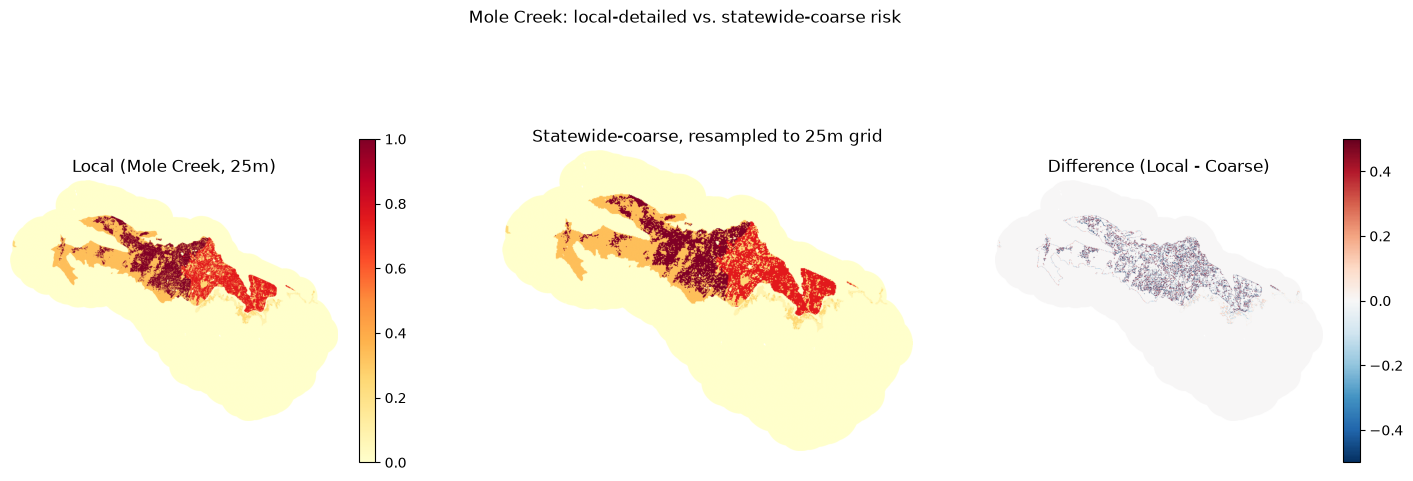

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
vmax = max(np.nanmax(risk_mc[valid]), np.nanmax(risk_tas_on_mc[valid]))

im0 = axes[0].imshow(np.where(valid, risk_mc, np.nan), cmap="YlOrRd", vmin=0, vmax=vmax)
axes[0].set_title("Local (Mole Creek, 25m)")
im1 = axes[1].imshow(np.where(valid, risk_tas_on_mc, np.nan), cmap="YlOrRd", vmin=0, vmax=vmax)
axes[1].set_title("Statewide-coarse, resampled to 25m grid")
im2 = axes[2].imshow(diff_map, cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[2].set_title("Difference (Local - Coarse)")

for ax in axes:
    ax.axis("off")
fig.colorbar(im0, ax=axes[0], shrink=0.7)
fig.colorbar(im2, ax=axes[2], shrink=0.7)
plt.suptitle("Mole Creek: local-detailed vs. statewide-coarse risk")
plt.show()

## 8.4 Per-named-area comparison

The table the plan itself suggests: Area | Statewide model | Local
model. Uses the same zonal-stats approach as Stages 6 and 7.

In [5]:
karst_mc = gpd.read_file(outpath / "karst_mc_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])]
karst_mc = karst_mc[karst_mc["karst_intensity"] > 0].copy()

rows = []
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src_local, \
     rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src_coarse:
    for name, group in karst_mc.groupby("KNAME"):
        geoms = list(group.geometry)
        local_img, _ = mask(src_local, geoms, crop=True, nodata=risk_mc_nodata)
        local_vals = local_img[0]
        local_vals = local_vals[local_vals != risk_mc_nodata]
        coarse_img, _ = mask(src_coarse, geoms, crop=True, nodata=src_coarse.nodata)
        coarse_vals = coarse_img[0]
        coarse_vals = coarse_vals[coarse_vals != src_coarse.nodata]
        rows.append({
            "KNAME": name,
            "local_mean_risk": local_vals.mean() if len(local_vals) else np.nan,
            "coarse_mean_risk": coarse_vals.mean() if len(coarse_vals) else np.nan,
        })

comparison = pd.DataFrame(rows).sort_values("local_mean_risk", ascending=False)
comparison["difference"] = comparison["local_mean_risk"] - comparison["coarse_mean_risk"]
comparison.to_csv(outpath / "stage8_comparison_table.csv", index=False)
print(comparison.to_string(index=False))

                                KNAME  local_mean_risk  coarse_mean_risk  difference
         Mole Creek  (Chudleigh Hill)         0.725857          0.743590   -0.017733
                           Mole Creek         0.601959          0.610350   -0.008391
Stockers Plain (Muddy Ck; Golden Vly)         0.547774          0.455882    0.091891
                              Lorinna         0.253799          0.250000    0.003799
              Meander - Western Creek         0.143417          0.143110    0.000307
                         Quamby Brook         0.105381          0.101190    0.004191
                        Golden Valley         0.091044          0.092377   -0.001333


## Where they agree, and where they genuinely diverge

**Agreement is very close for the two dominant, well-known systems** —
Mole Creek (0.602 local vs. 0.610 coarse) and Mole Creek (Chudleigh
Hill) (0.726 vs. 0.744) — differences under 0.02, well within noise.

**One real, worth-discussing divergence:** Stockers Plain (Muddy
Creek; Golden Valley) — 0.548 local vs. 0.456 coarse, a 0.09 gap, the
largest of any named area. Two plausible causes, both legitimate to
raise in `discussion.md` rather than picking one without evidence:

1. **Land-use loading resolution** — Stage 5 loaded DEA land cover at
   native ~30m before resampling to 25m; Stage 7 loaded it directly at
   100m. A smaller or more heterogeneous karst polygon (like Stockers
   Plain, which is a smaller/composite named area) is more sensitive to
   this than a large system like Mole Creek itself, where both
   resolutions average out to a similar mix either way.
2. **Karst rasterisation resolution** — at 100m, a small polygon can be
   completely swallowed by a single coarse pixel that also covers
   substantial non-karst land, diluting its intensity score; at 25m
   the same polygon gets its own pixels.

Both point the same direction: **smaller, more heterogeneous karst
areas are where scale genuinely matters**; large, dominant systems are
robust to it. That's a defensible, evidence-based conclusion — not
"the model is validated," which would overstate what a 7-area Mole
Creek check can actually show.

## Stage 8 outputs

- `stage8_comparison_table.csv` — per-named-area local vs. coarse comparison

**Next (Stage 9):** sensitivity analysis — alternative weight emphases,
the optional rainfall experiment (`KAVRAIN`), and the multi-year
land-use trend now made easy by the `src/landuse.py` refactor.